In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from sklearn import linear_model,metrics,preprocessing

In [90]:
train=np.loadtxt("q5_train.csv",skiprows=1,delimiter=",")
test=np.loadtxt("q5_test.csv",skiprows=1,delimiter=",")
X_train, y_train = train[:, :-1], train[:, -1]
X_test = test[:, 1:]

In [91]:
std=preprocessing.RobustScaler()
std.fit(X_train)
std_X_train=std.transform(X_train)
std_X_test=std.transform(X_test)

x = std_X_train[:, 7]
median = np.median(x)
mad = np.median(np.abs(x - median))
mask = np.abs(x - median) <= 3 * mad

X_train_clean = std_X_train[mask]
y_train_clean = y_train[mask]
train_clean = train[mask]

print(X_train_clean.shape, X_train.shape)

ValueError: X has 7 features, but RobustScaler is expecting 8 features as input.

# Corr Coeff

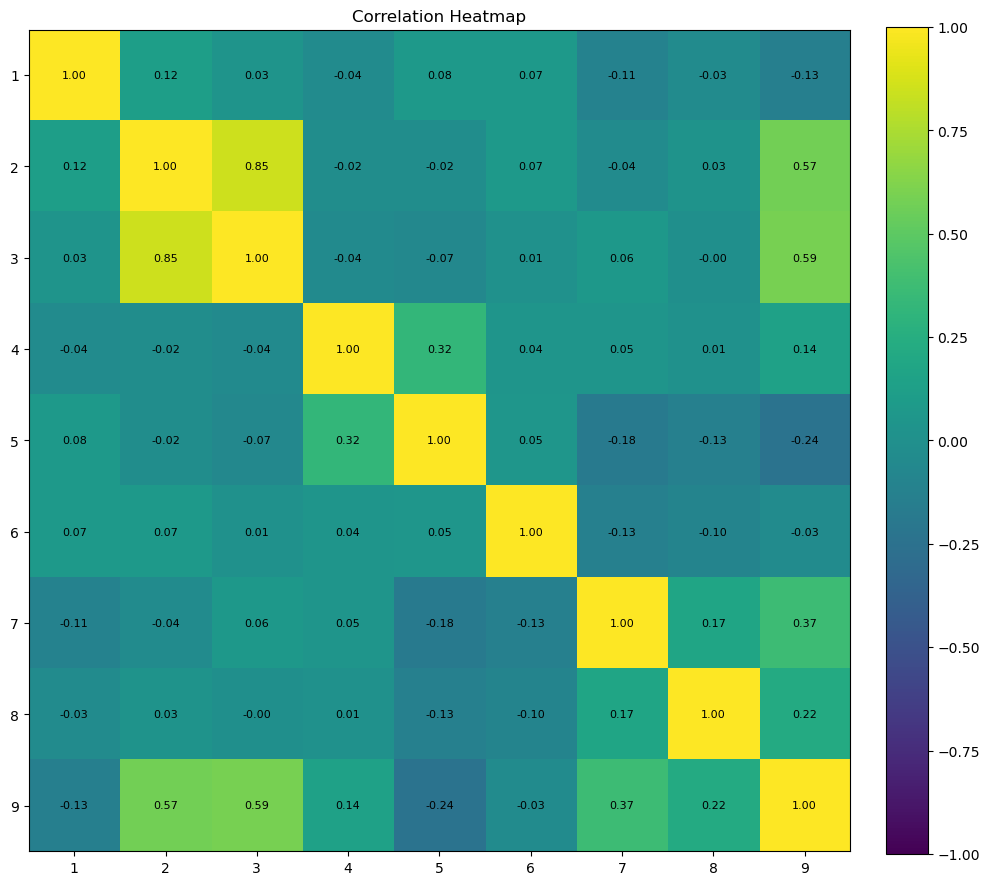

In [33]:
corr = np.corrcoef(train_clean, rowvar=False)

n = corr.shape[0]
labels = np.arange(1, n + 1)

plt.figure(figsize=(10, 10))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(n), labels)
plt.yticks(np.arange(n), labels)

# annotate values
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter plot

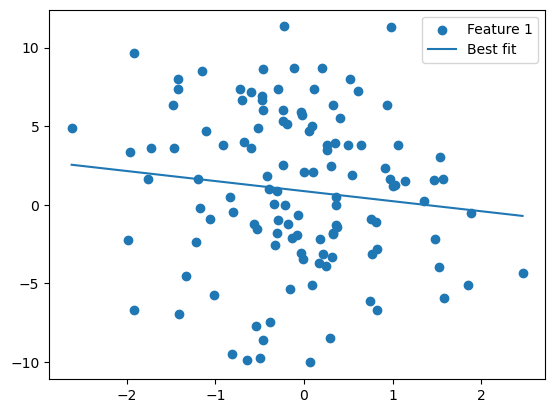

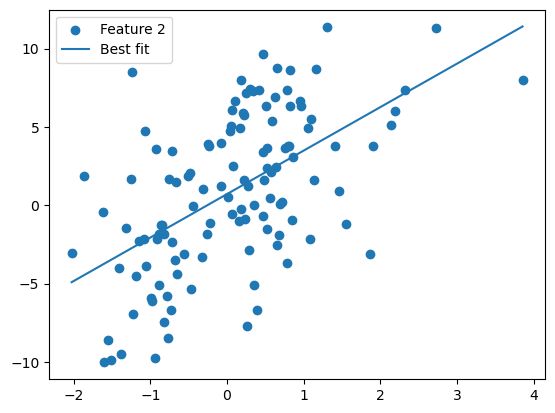

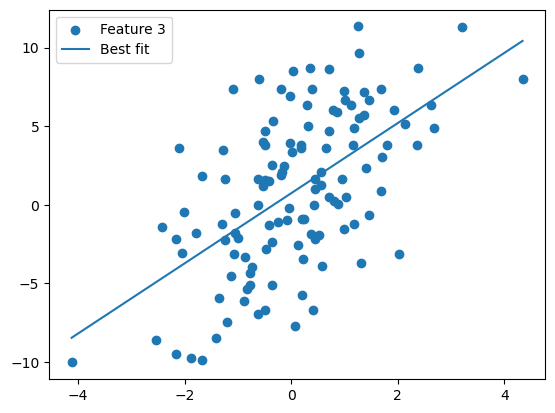

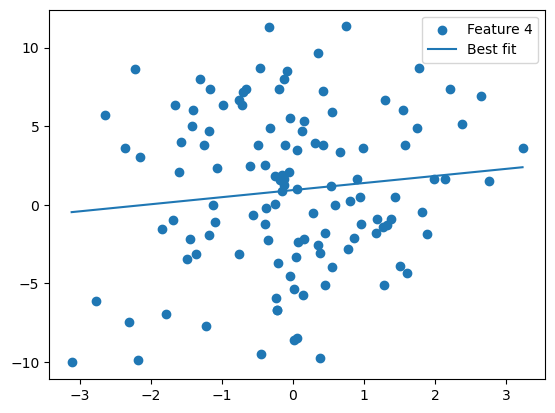

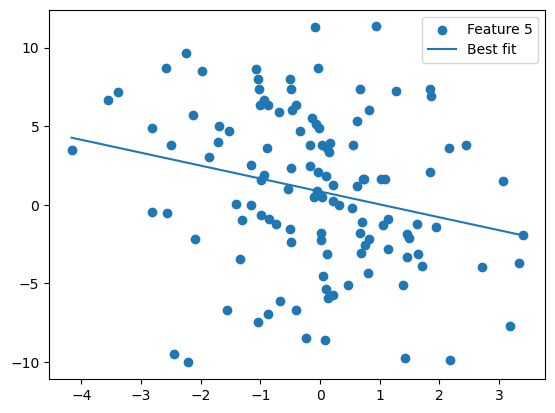

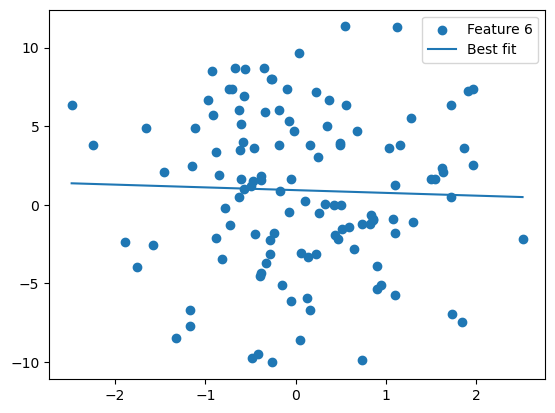

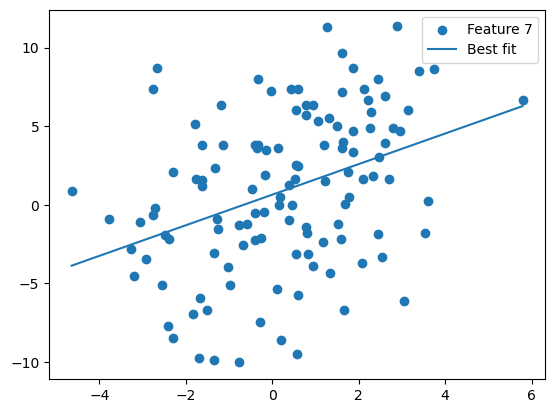

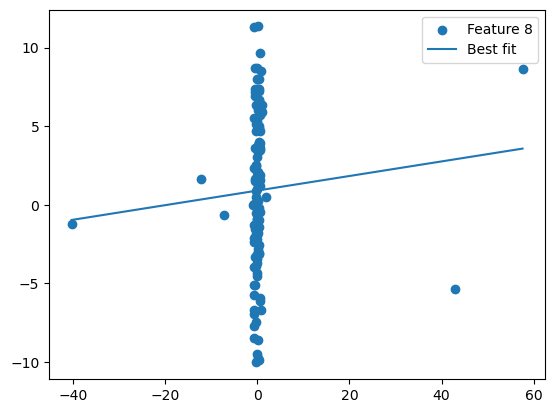

In [34]:
for i in range(X_train.shape[1]):
    x = X_train[:, i]
    plt.figure()
    plt.scatter(x, y_train, label=f'Feature {i+1}')
    plt.plot(np.sort(x), np.polyval(np.polyfit(x, y_train, 1), np.sort(x)), label='Best fit')
    plt.legend()
    plt.show()

# Normal

[-0.53050101  1.90111611  0.92090278  0.84520188 -0.72493984 -0.02067353
  0.8199396   0.04904944]
8


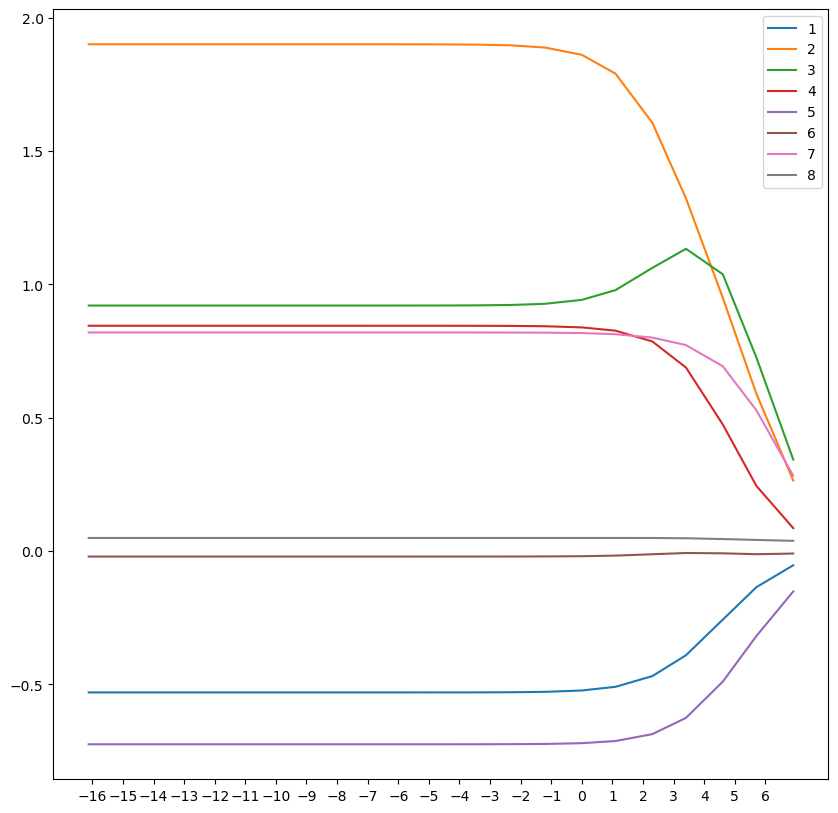

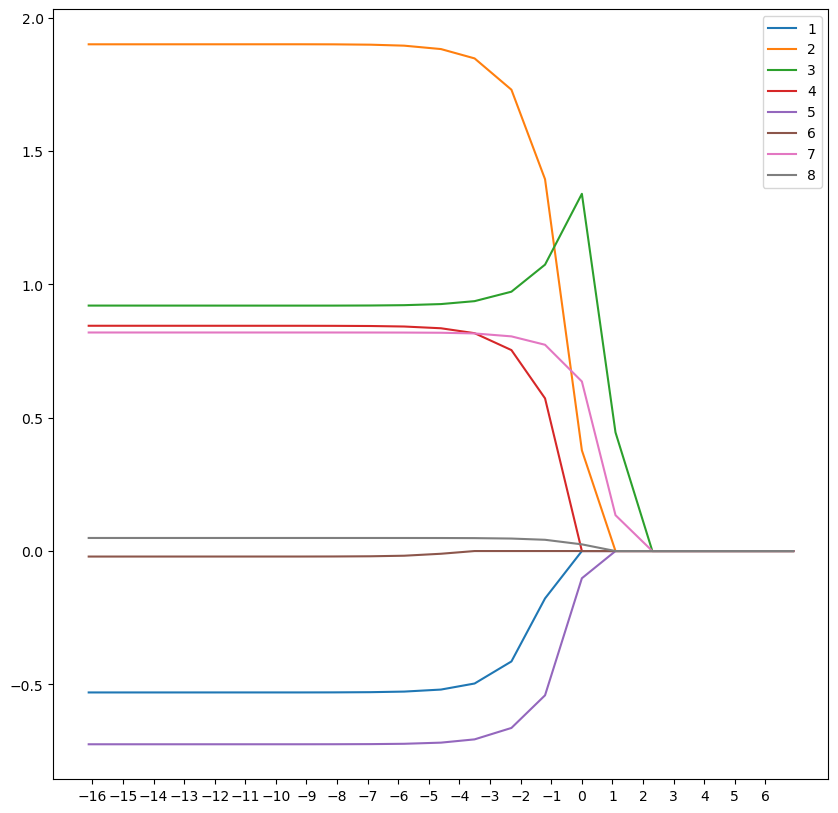

In [35]:
alphas = [1e-7, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train,y_train)
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()

coeffs=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()


# Standardised

[-0.50644892  2.70114963  1.57100584  1.275197   -1.27291925 -0.02704547
  2.34580761  0.03376743]
8


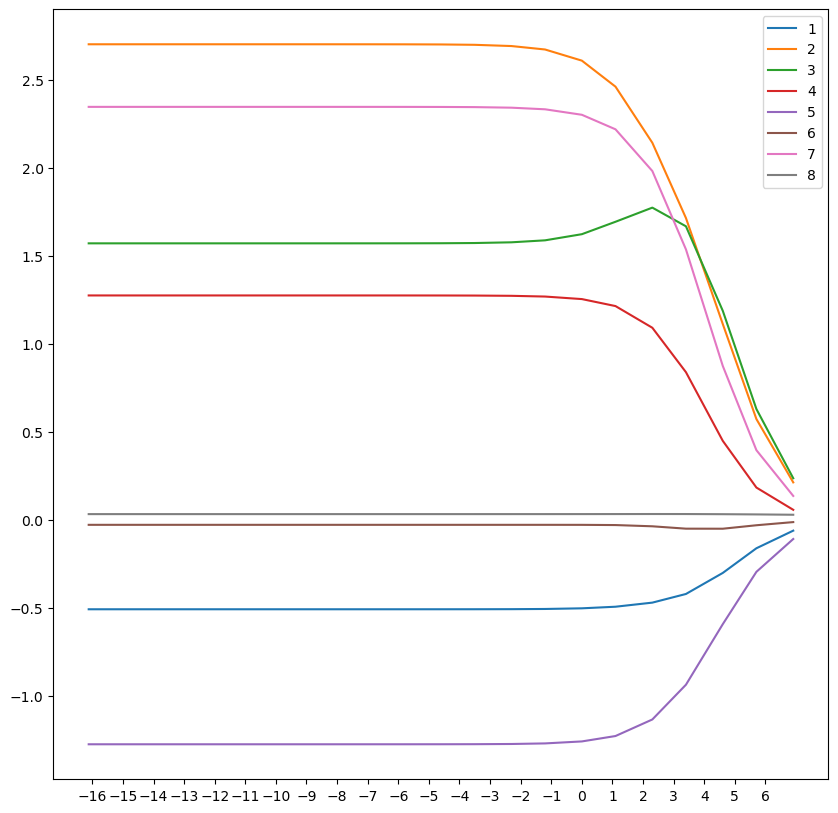

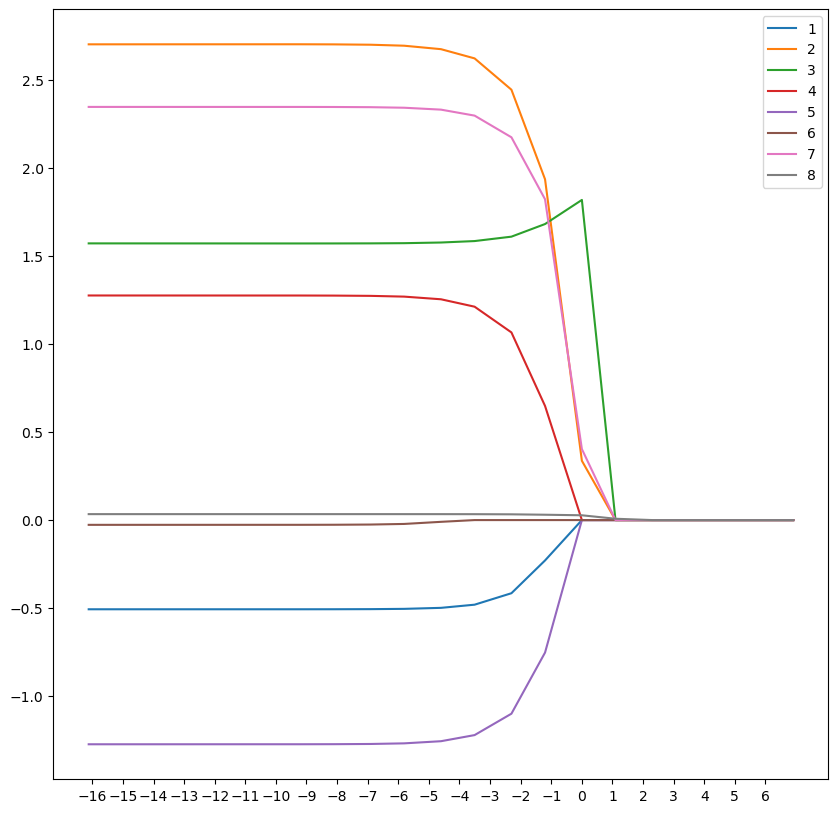

In [36]:
alphas = [1e-7, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(std_X_train,y_train)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(std_X_train,y_train)
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()

coeffs=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(std_X_train,y_train)
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()


# Outliers Removed (after standardising)

[-0.66543444  2.71791732  1.61474317  1.25899528 -1.18044657 -0.01938702
  2.17804434  1.01507285]
8


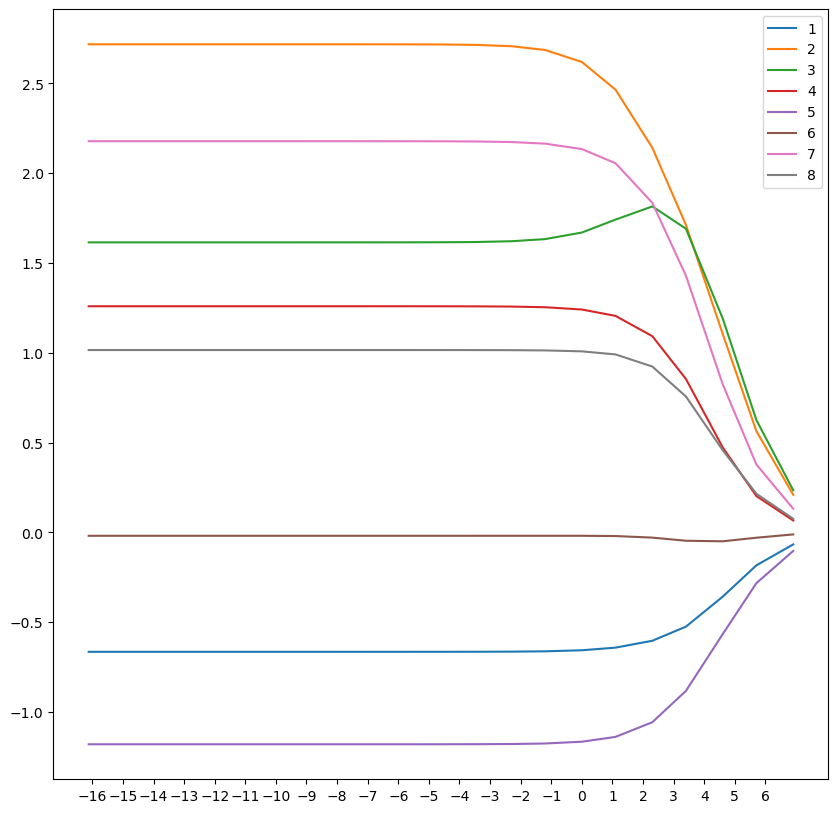

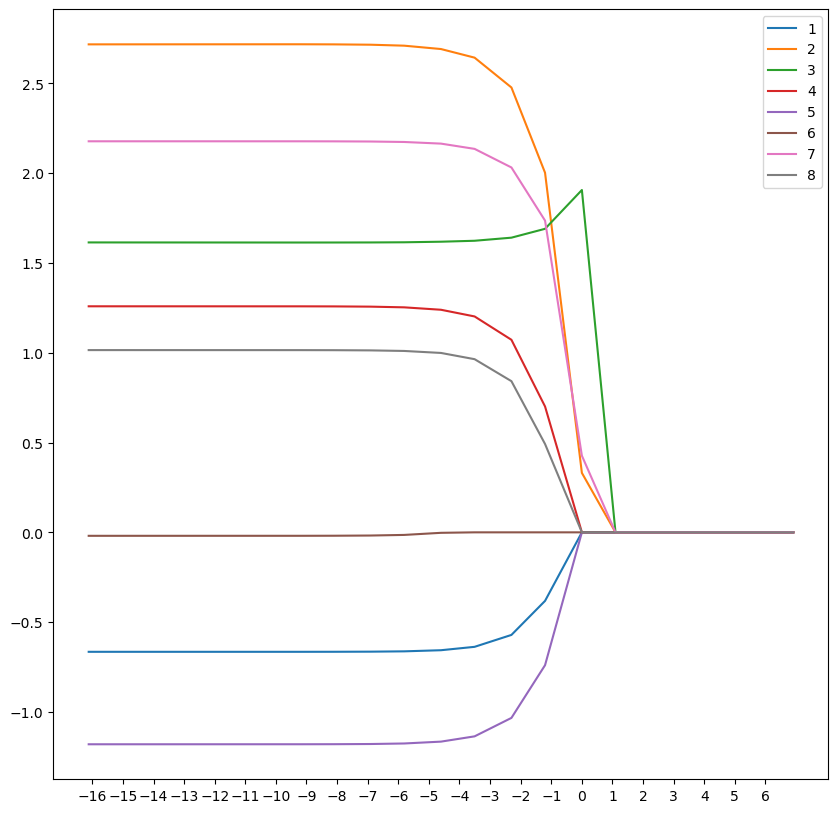

In [37]:
alphas = [1e-7, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(X_train_clean,y_train_clean)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train_clean,y_train_clean)
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()

coeffs=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train_clean,y_train_clean)
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()


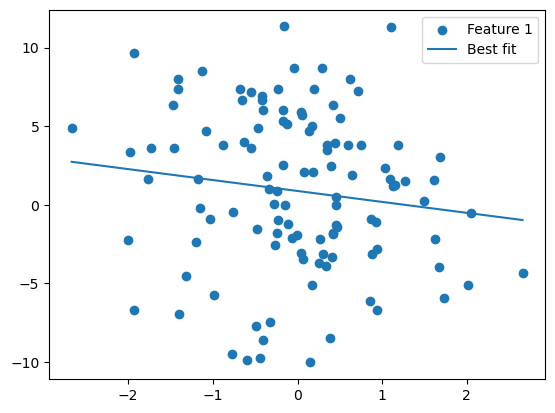

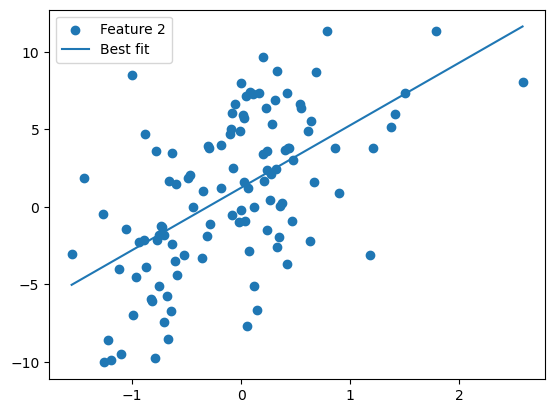

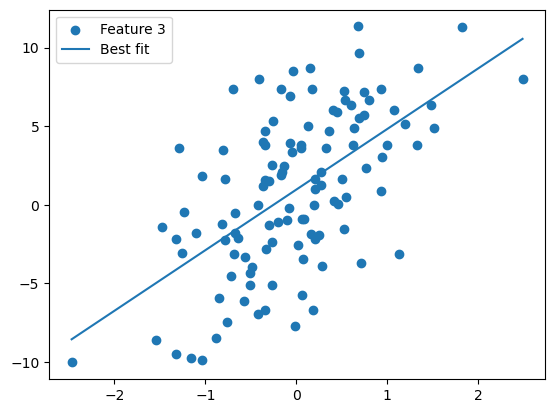

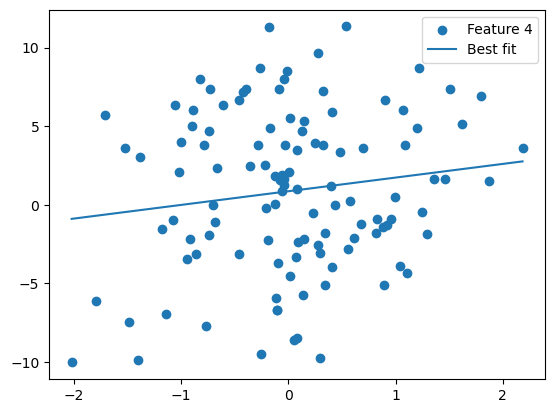

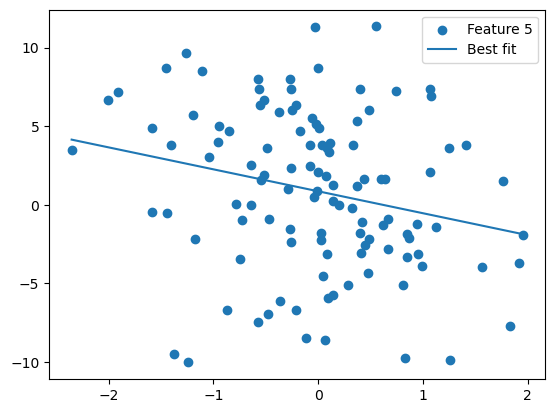

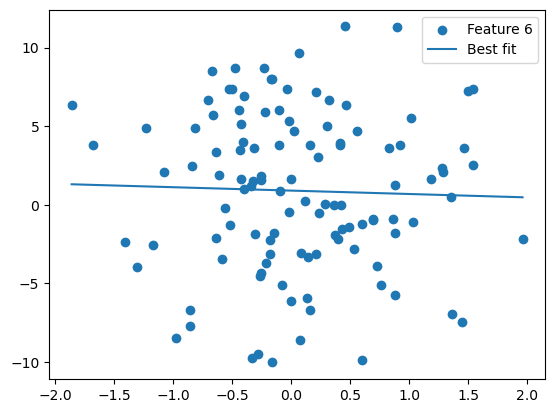

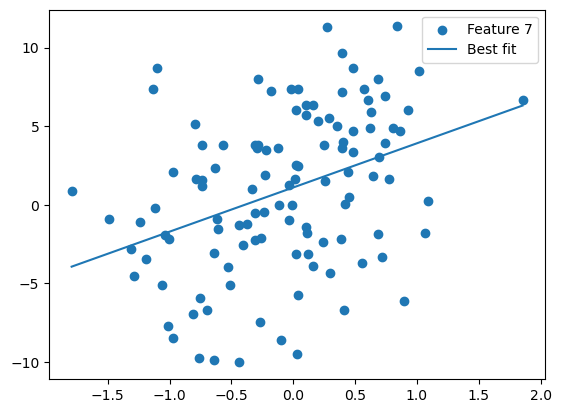

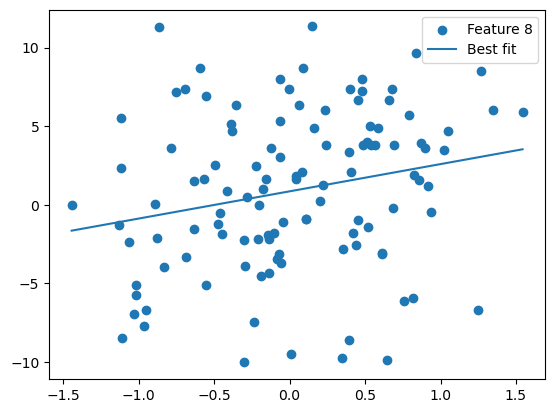

In [38]:
for i in range(X_train_clean.shape[1]):
    x = X_train_clean[:, i]
    plt.figure()
    plt.scatter(x, y_train_clean, label=f'Feature {i+1}')
    plt.plot(np.sort(x), np.polyval(np.polyfit(x, y_train_clean, 1), np.sort(x)), label='Best fit')
    plt.legend()
    plt.show()

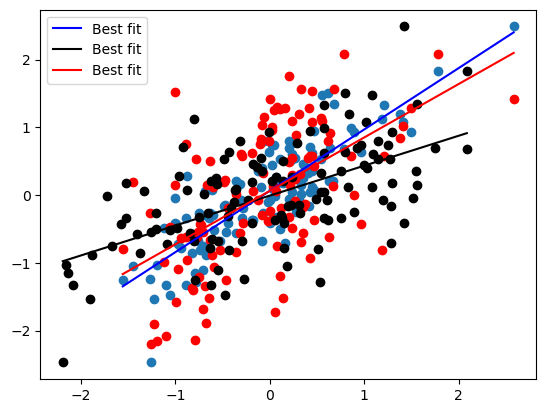

In [39]:
x1 = std_X_train[:, 1]
x2 = std_X_train[:, 2]
std_y_train = (y_train - np.mean(y_train)) / np.std(y_train)
plt.figure()
plt.scatter(x1, x2)
plt.scatter(x1, std_y_train, color="red")
plt.scatter(std_y_train,x2, color="black")
plt.plot(np.sort(x1), np.polyval(np.polyfit(x1, x2, 1), np.sort(x1)), label='Best fit', color="blue")
plt.plot(np.sort(std_y_train), np.polyval(np.polyfit(std_y_train, x2, 1), np.sort(std_y_train)), label='Best fit', color="black")
plt.plot(np.sort(x1), np.polyval(np.polyfit(x1, std_y_train, 1), np.sort(x1)), label='Best fit', color="red")
plt.legend()
plt.show()

# Final

In [40]:
def train_and_write_csv(X_train, y_train, test_csv, feature_indices, output_csv="predictions.csv"):
    test = np.loadtxt(test_csv, skiprows=1, delimiter=",")
    test_ids = test[:, 0]
    X_test = test[:, 1:]
    X_train_sel = X_train[:, feature_indices]
    X_test_sel = std_X_test[:, feature_indices]
    model = sklearn.linear_model.Ridge(alpha=0)
    model.fit(X_train_sel, y_train)

    y_pred = model.predict(X_test_sel)

    output = np.column_stack((test_ids.astype(int), y_pred))
    np.savetxt(output_csv,output,delimiter=",",header="Id,y",comments="")

    print(f"Saved predictions to {output_csv}")

train_and_write_csv(std_X_train, y_train, "q5_test.csv",[0, 1, 3, 4, 6],"q5_predictions.csv") #3,6,8

Saved predictions to q5_predictions.csv


In [41]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

def cv_best_lambda_ridge_lasso(X, y, lambdas=np.logspace(-6, 4, 30), k=5, random_state=42, max_iter=20000):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)

    def cv_mse_for_model(model_ctor):
        mses = []
        for lam in lambdas:
            fold_mses = []
            for tr_idx, va_idx in kf.split(X):
                X_tr, X_va = X[tr_idx], X[va_idx]
                y_tr, y_va = y[tr_idx], y[va_idx]

                pipe = Pipeline([
                    ("scaler", StandardScaler()),      # important for Ridge/Lasso
                    ("model", model_ctor(lam))
                ])
                pipe.fit(X_tr, y_tr)
                y_hat = pipe.predict(X_va)
                fold_mses.append(mean_squared_error(y_va, y_hat))
            mses.append(np.mean(fold_mses))
        mses = np.array(mses)
        best_i = int(np.argmin(mses))
        return float(lambdas[best_i]), float(mses[best_i]), mses

    best_lam_ridge, best_mse_ridge, ridge_curve = cv_mse_for_model(
        lambda lam: Ridge(alpha=lam, fit_intercept=True, random_state=random_state)
    )

    best_lam_lasso, best_mse_lasso, lasso_curve = cv_mse_for_model(
        lambda lam: Lasso(alpha=lam, fit_intercept=True, max_iter=max_iter, random_state=random_state)
    )

    print(f"Ridge: best lambda = {best_lam_ridge:.6g}, best CV MSE = {best_mse_ridge:.6g}")
    print(f"Lasso: best lambda = {best_lam_lasso:.6g}, best CV MSE = {best_mse_lasso:.6g}")

    return {
        "ridge": {"best_lambda": best_lam_ridge, "best_mse": best_mse_ridge, "mse_curve": ridge_curve, "lambdas": lambdas},
        "lasso": {"best_lambda": best_lam_lasso, "best_mse": best_mse_lasso, "mse_curve": lasso_curve, "lambdas": lambdas},
    }

train = np.loadtxt("q5_train.csv", skiprows=1, delimiter=",")
X_train_this, y_train_this = train[:, :-1][:,[0, 1, 3, 4, 6]], train[:, -1]
results = cv_best_lambda_ridge_lasso(X_train, y_train, k=5)


Ridge: best lambda = 7.88046, best CV MSE = 13.0157
Lasso: best lambda = 0.030392, best CV MSE = 13.1521


# Replace blue with red selectively (x1 with x2)

Variance from line (x1): 0.6866719187458814
Variance from line (x2): 0.6633474805736245


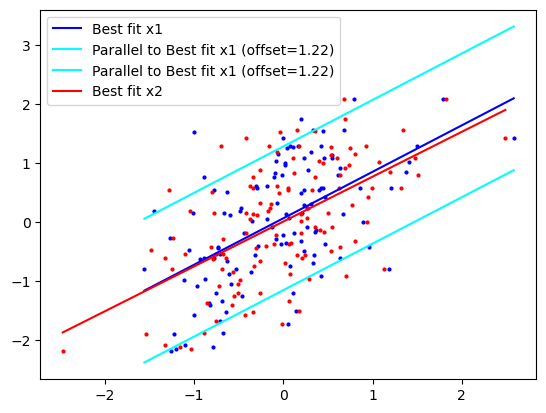

In [42]:
import numpy as np
import matplotlib.pyplot as plt

x1 = std_X_train[:, 1]
x2 = std_X_train[:, 2]

std_y_train = (y_train - np.mean(y_train)) / np.std(y_train)

# Fit lines
coef1 = np.polyfit(x1, std_y_train, 1)
coef2 = np.polyfit(x2, std_y_train, 1)

yhat1 = np.polyval(coef1, x1)
yhat2 = np.polyval(coef2, x2)

# Residuals
res1 = std_y_train - yhat1
res2 = std_y_train - yhat2

# Variance of residuals
var1 = np.var(res1)
var2 = np.var(res2)

print("Variance from line (x1):", var1)
print("Variance from line (x2):", var2)

# Define an offset for the parallel line
perpendicular_offset = 1.22 # You can change this value to adjust the distance

# Plot
plt.figure()
plt.scatter(x1, std_y_train, s=4, color="blue")
plt.scatter(x2, std_y_train, s=4, color="red")

plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)),
    color="blue", label="Best fit x1"
)

# Plot the new parallel line
plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)) + perpendicular_offset, # Add the offset here
    color="cyan", label=f"Parallel to Best fit x1 (offset={perpendicular_offset})"
)
plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)) - perpendicular_offset, # Add the offset here
    color="cyan", label=f"Parallel to Best fit x1 (offset={perpendicular_offset})"
)

plt.plot(
    np.sort(x2),
    np.polyval(coef2, np.sort(x2)),
    color="red", label="Best fit x2"
)

plt.legend()
plt.show()

In [43]:
upper_bound = np.polyval(coef1, x1) + perpendicular_offset
lower_bound = np.polyval(coef1, x1) - perpendicular_offset
abs_res1 = np.abs(res1)
abs_res2 = np.abs(res2)

outlier_x1 = (std_y_train > upper_bound) | (std_y_train < lower_bound)
better_fit_x2 = (abs_res2 < abs_res1)

conditional_replacement_indices = np.where(outlier_x1 & better_fit_x2)

print(f"Number of conditional replacement indices identified: {len(conditional_replacement_indices[0])}")
x1_modified = x1.copy()
x1_modified[conditional_replacement_indices] = x2[conditional_replacement_indices]

Number of conditional replacement indices identified: 13


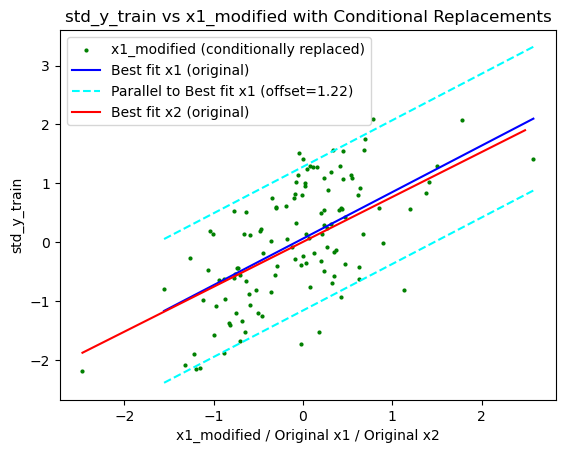

In [44]:
plt.figure()
plt.scatter(x1_modified, std_y_train, s=4, color="green", label="x1_modified (conditionally replaced)")

plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)),
    color="blue", label="Best fit x1 (original)"
)

plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)) + perpendicular_offset,
    color="cyan", label=f"Parallel to Best fit x1 (offset={perpendicular_offset})", linestyle='--'
)
plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)) - perpendicular_offset,
    color="cyan", linestyle='--'
)

plt.plot(
    np.sort(x2),
    np.polyval(coef2, np.sort(x2)),
    color="red", label="Best fit x2 (original)"
)

plt.title("std_y_train vs x1_modified with Conditional Replacements")
plt.xlabel("x1_modified / Original x1 / Original x2")
plt.ylabel("std_y_train")
plt.legend()
plt.show()


In [45]:
variance_x1_modified = np.var(x1_modified)
print(f"Variance of x1_modified: {variance_x1_modified}")

Variance of x1_modified: 0.5312864449901508


In [46]:
std_X_train_modified=std_X_train
std_X_train_modified[:,1]=x1_modified
def train_and_write_csv(X_train, y_train, test_csv, feature_indices, output_csv="predictions.csv"):
    test = np.loadtxt(test_csv, skiprows=1, delimiter=",")
    test_ids = test[:, 0]
    X_test = test[:, 1:]
    X_train_sel = X_train[:, feature_indices]
    X_test_sel = std_X_test[:, feature_indices]
    model = sklearn.linear_model.Ridge(alpha=0)
    model.fit(X_train_sel, y_train)
    print(model.coef_)
    y_pred = model.predict(X_test_sel)
    

    output = np.column_stack((test_ids.astype(int), y_pred))
    np.savetxt(output_csv,output,delimiter=",",header="Id,y",comments="")

    print(f"Saved predictions to {output_csv}")

train_and_write_csv(std_X_train_modified, y_train, "q5_test.csv",[0, 1, 3, 4, 6],"q5_predictions.csv") #3,6,8

[-0.48274487  4.30488529  1.08584433 -1.27369257  2.28671815]
Saved predictions to q5_predictions.csv


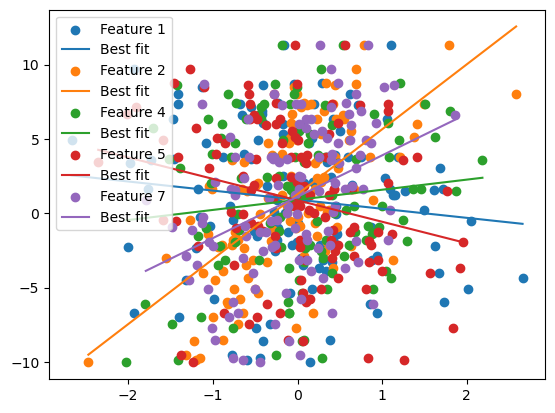

In [83]:
plt.figure()
for i in [0,1,3,4,6]:
    x = std_X_train[:, i]
    plt.scatter(x, y_train, label=f'Feature {i+1}')
    plt.plot(np.sort(x), np.polyval(np.polyfit(x, y_train, 1), np.sort(x)), label='Best fit')
    plt.legend()


In [87]:
x0=std_X_train[:,0]
x4=std_X_train[:,0]

from sklearn.linear_model import LassoCV
alphas = np.logspace(-4, 2, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(std_X_train_modified[:,[0,3,4]], y_train)

best_alpha = lasso_cv.alpha_
print(best_alpha)

0.035111917342151314


In [88]:
las=linear_model.Lasso(alpha=best_alpha)
las.fit(std_X_train_modified[:,[0,3,4]], y_train)
print(las.coef_)
test_ids = test[:, 0]
# y_pred=las.predict(X_test[:, [0, 1, 3, 4, 6]])
# output = np.column_stack((test_ids.astype(int), y_pred))
# np.savetxt("q5_predictions.csv",output,delimiter=",",header="Id,y",comments="")

[-0.41045378  1.19868878 -1.74367525]


In [82]:
coeff=[-0.41045378,4.26885636,1.19868878,-1.27369257,2.62000967]
coeff=np.array(coeff)
X__=std_X_test[:,[0, 1, 3, 4, 6]]
y=X__@coeff.T
print(y.shape)
output = np.column_stack((test_ids.astype(int), y))
np.savetxt("q5_predictions.csv",output,delimiter=",",header="Id,y",comments="")

(500,)
